# ADM Assignment 5

## Imports

In [36]:
import pandas as pd
import json
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## Task 1

In [3]:
def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield json.loads(l)

def getDF(path):
  data = []
  for d in parse(path):
    # Extract only the keys you need for the assignment
    filtered_row = {
        'user_id': d.get('reviewerID'),
        'asin': d.get('asin'),
        'rating': d.get('overall'),
        'timestamp': d.get('unixReviewTime')
    }
    data.append(filtered_row)

  # Create the DataFrame directly from the list of dictionaries
  return pd.DataFrame(data)

In [4]:
df = getDF('./data/Sports_and_Outdoors.json.gz')
df5 = getDF('./data/Sports_and_Outdoors_5.json.gz')

5-core version contains only users and products that have at least 5 interactions

In [5]:
print(df.shape)
print(df5.shape)

(12980837, 4)
(2839940, 4)


### Number of interactions

In [6]:
df['asin'].value_counts()

asin
B00V6JAEDC    10226
B0017IHRNM     9472
B00G7H793G     8801
B0013092CS     8592
B00FO9ZRYQ     8591
              ...  
B00I41WDEI        1
B00I41Z5P2        1
B00I424692        1
B00I41XZU4        1
B00I41Z53Y        1
Name: count, Length: 957764, dtype: int64

In [7]:
df5['asin'].value_counts()

asin
B0010O748Q    4163
B0012Q2S4W    3387
B0014VX2M2    3190
B0015LT03G    3148
B0015LY0DG    3146
              ... 
B0016KB9BW       1
B0017L4S68       1
B0017KL1LE       1
B0017IF054       1
B001668H1G       1
Name: count, Length: 104687, dtype: int64

### Distribution of users number of interactions

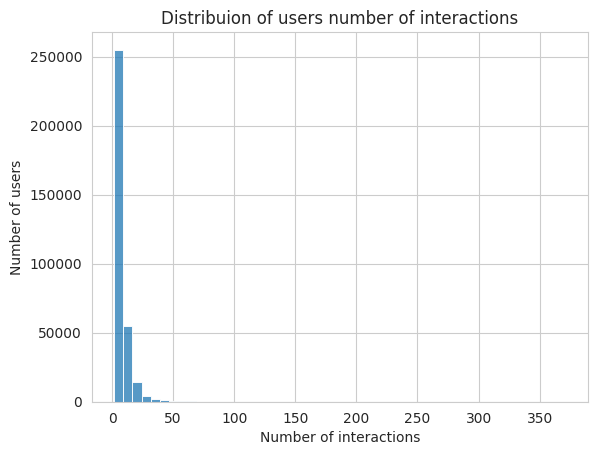

In [8]:
sns.histplot(df5['user_id'].value_counts(), bins=50)
plt.title('Distribuion of users number of interactions')
plt.xlabel('Number of interactions')
plt.ylabel('Number of users')
plt.show()

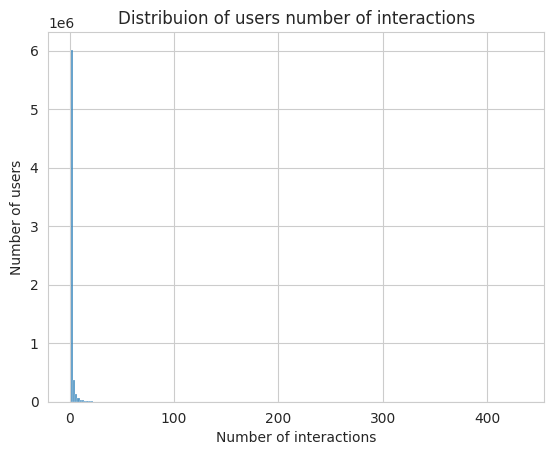

In [9]:
sns.histplot(df['user_id'].value_counts(), bins=200)
plt.title('Distribuion of users number of interactions')
plt.xlabel('Number of interactions')
plt.ylabel('Number of users')
plt.show()

### Sparsity (how many of the possible user-item pairs are present in the data)

In [10]:
len(df5) / (df5['user_id'].nunique() * df5['asin'].nunique())

8.160072023747047e-05

In [11]:
len(df) / (df['user_id'].nunique() * df['asin'].nunique())

2.0218532739806794e-06

### Check for duplicates of contradictory data

In [12]:
duplicates_df5 = df5[df5.duplicated(subset=['user_id', 'asin'], keep=False)]
rating_counts = duplicates_df5.groupby(['user_id', 'asin'])['rating'].nunique()
contradictory_df5 = rating_counts[rating_counts > 1]
len(contradictory_df5)

1825

In [13]:
duplicates_df = df[df.duplicated(subset=['user_id', 'asin'], keep=False)]
rating_counts = duplicates_df.groupby(['user_id', 'asin'])['rating'].nunique()
contradictory_df = rating_counts[rating_counts > 1]
len(contradictory_df)

3074

### Other plots

#### Distribution of ratings

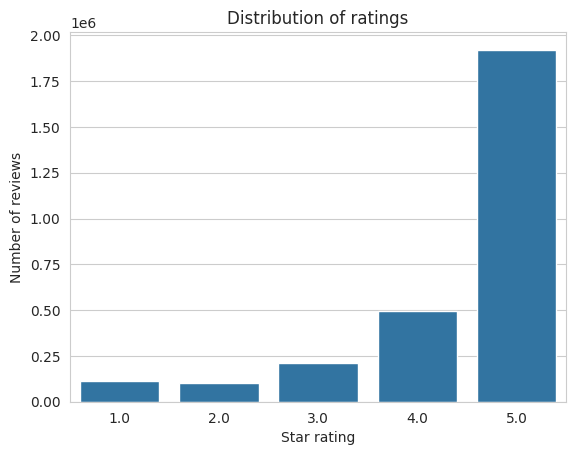

In [14]:
sns.countplot(data=df5, x='rating')
plt.title('Distribution of ratings')
plt.xlabel('Star rating')
plt.ylabel('Number of reviews')
plt.show()

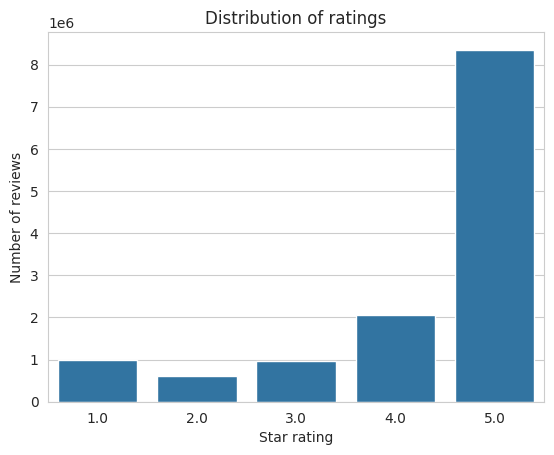

In [15]:
sns.countplot(data=df, x='rating')
plt.title('Distribution of ratings')
plt.xlabel('Star rating')
plt.ylabel('Number of reviews')
plt.show()

#### Item interaction distribution

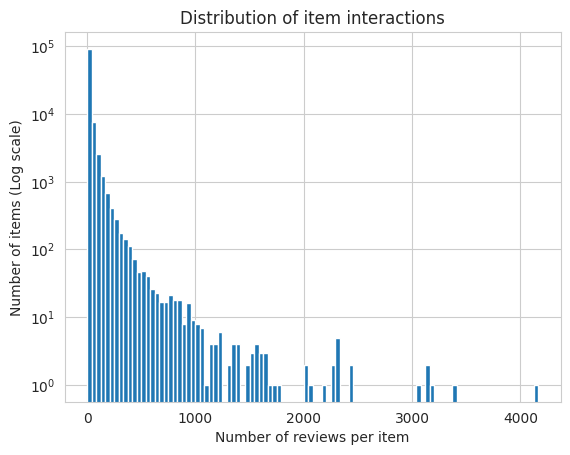

In [16]:
plt.hist(df5['asin'].value_counts(), bins=100, log=True)
plt.title('Distribution of item interactions')
plt.xlabel('Number of reviews per item')
plt.ylabel('Number of items (Log scale)')
plt.show()

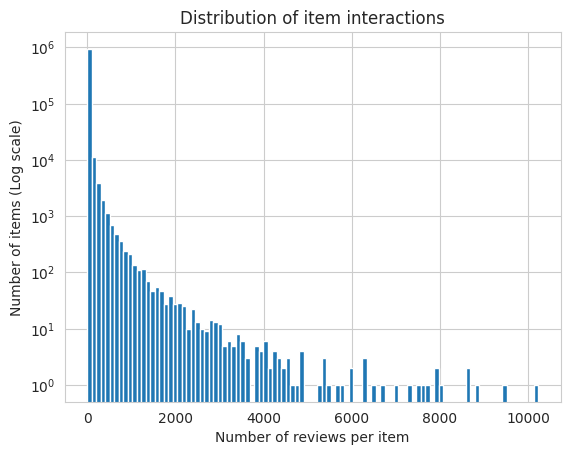

In [17]:
plt.hist(df['asin'].value_counts(), bins=100, log=True)
plt.title('Distribution of item interactions')
plt.xlabel('Number of reviews per item')
plt.ylabel('Number of items (Log scale)')
plt.show()

### Consider the following train-test split procedures. What are their advantages and disadvantages? Discuss it in terms of user and item representation, biases, leakage, and suitability for the ranking task.
- Randomly select 20% of all interactions.
    * Advantages: Easy to implement
    * Disadvantages: Possible bias from users, Possible leakage from users. (Training on future interactions and predicting past interactions, Some users may be completely in test set.)
    * Not suitable for ranking task
- Randomly select 20% of users and put all their interactions in the test set.
    * Advantages: No data leakage, No bias
    * Disadvantages: User cold start problem (No info on some users in test set)
    * Not suitable for ranking task
- Select 20% of interactions for each user at random.
    * Advantages: Good user/item representations
    * Disadvantages: Possible user bias, Possible data leakage (user buys a -> b -> c, but we take b to test set)
    * Not suitable for ranking task
- Select the most recent 20% of interactions for each user.
    * Advantages: No leakage
    * Disadvantages: Possible bias (last user interaction may be 4 years ago)
    * Suitable for ranking task
- Select a fixed number of the most recent interactions for each user to obtain around 20% of the data.
    * Advantages: No leakage
    * Disadvantages: Possible bias (last user interaction may be 4 years ago)
    * Suitable for ranking task
- Select the most recent 20% of all interactions.
    * Advantages: No bias, No leakage
    * Disadvantages: Possible cold start for some users.
    * Suitable for ranking task

In [18]:
sorted_df5 = df5.sort_values(by=['user_id', 'timestamp'])
test_set = sorted_df5.groupby('user_id').tail(2)
train_set = sorted_df5.drop(test_set.index)

In [19]:
print(f"Total interactions: {len(df5)}")
print(f"Train set interactions: {len(train_set)}")
print(f"Test set interactions: {len(test_set)}")

Total interactions: 2839940
Train set interactions: 2175046
Test set interactions: 664894


### Discuss how you can transform the data into boolean feedback:
* If users product rating is higher than user mean -> true
* Everything is true since it is reviewed and that means the user has bought the item.
* Ratings 4/5 -> true

## Task 2

In [20]:
item_popularity = train_set['asin'].value_counts()
top_items = item_popularity.index.tolist()

In [21]:
def recommend(user_id, train_data, top_items, k=10):
    seen = set(train_data[train_data['user_id'] == user_id]['asin'])

    recommendations = []

    for item in top_items:
        if item not in seen and k > 0:
            recommendations.append(item)
            k -= 1
    return recommendations

In [22]:
sample_user = test_set['user_id'].iloc[0]
recs = recommend(sample_user, train_set, top_items, k=10)

print(f"Top 10 recommendations for user {sample_user}:")
print(recs)

Top 10 recommendations for user A0001528BGUBOEVR6T5U:
['B0010O748Q', 'B0012Q2S4W', 'B00136X6VU', 'B0014VX2M2', 'B000YBAKU0', 'B00RM8I0LE', 'B00SI9UB7M', 'B000VAPCU2', 'B0015LY0DG', 'B0013R67A6']


In [23]:
user_mapping = {user: i for i, user in enumerate(df5['user_id'].unique())}
item_mapping = {item: i for i, item in enumerate(df5['asin'].unique())}

train_set['user_idx'] = train_set['user_id'].map(user_mapping)
train_set['item_idx'] = train_set['asin'].map(item_mapping)

test_set['user_idx'] = test_set['user_id'].map(user_mapping)
test_set['item_idx'] = test_set['asin'].map(item_mapping)

/tmp/ipykernel_43012/3257012476.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set['user_idx'] = test_set['user_id'].map(user_mapping)
/tmp/ipykernel_43012/3257012476.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set['item_idx'] = test_set['asin'].map(item_mapping)


In [29]:
class MseDataset(Dataset):
    def __init__(self, df):
        self.users = df['user_idx'].values
        self.items = df['item_idx'].values
        self.ratings = df['rating'].values
        self.max_rating = 5.0

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        scaled_r = (self.ratings[idx] - 1) / (self.max_rating - 1)

        return torch.tensor(self.users[idx], dtype=torch.long), \
               torch.tensor(self.items[idx], dtype=torch.long), \
               torch.tensor(scaled_r, dtype=torch.float)

In [30]:
class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, user_indexes, item_indexes):
        user_vectors = self.user_emb(user_indexes)
        item_vectors = self.item_emb(item_indexes)
        return user_vectors, item_vectors


In [31]:
def mse_loss(user_vectors, item_vectors, scaled_ratings, l2_reg_u, l2_reg_i):

    dot_product = (user_vectors * item_vectors).sum(dim=1) # (user_vectors @ item_vectors).diag()
    predictions = torch.sigmoid(dot_product)

    base_loss = F.mse_loss(predictions, scaled_ratings, reduction='sum')

    reg_loss = (l2_reg_u * user_vectors.norm() ** 2) + (l2_reg_i * item_vectors.norm() ** 2)

    return base_loss + reg_loss


In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 10
batch_size = 1024
learning_rate = 0.001
l2_reg = 1e-4

In [46]:
train_dataset = MseDataset(train_set)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

num_users = len(user_mapping)
num_items = len(item_mapping)

In [47]:
def evaluate_metrics(model, train_df, test_df, device, k=20):
    model.eval()

    test_interacts = test_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
    train_interacts = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    hits, recalls, ndcgs, mrrs = [], [], [], []

    with torch.no_grad():
        all_item_embs = model.item_emb.weight

        for user_idx, true_items in test_interacts.items():
            user_tensor = torch.tensor([user_idx], dtype=torch.long, device=device)
            user_emb = model.user_emb(user_tensor)

            # Dot product to get scores for all items at once
            scores = torch.matmul(user_emb, all_item_embs.T).squeeze()

            # Mask out items the user already interacted with during training
            if user_idx in train_interacts:
                scores[list(train_interacts[user_idx])] = -float('inf')

            _, top_k_items = torch.topk(scores, k)
            top_k_items = top_k_items.cpu().tolist()

            hit = 0
            dcg = 0
            mrr = 0

            for rank, item in enumerate(top_k_items):
                if item in true_items:
                    hit = 1
                    dcg += 1.0 / np.log2(rank + 2)
                    if mrr == 0:
                        mrr = 1.0 / (rank + 1)

            # Ideal DCG for normalization
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(true_items), k)))

            hits.append(hit)
            recalls.append(sum(1 for i in top_k_items if i in true_items) / len(true_items))
            ndcgs.append(dcg / idcg if idcg > 0 else 0)
            mrrs.append(mrr)

    return {
        'Recall@20': np.mean(recalls),
        'Hit-rate@20': np.mean(hits),
        'NDCG@20': np.mean(ndcgs),
        'MRR@20': np.mean(mrrs)
    }

In [48]:
results_summary = []

for dim in [16, 32, 64, 128]:
    print(f"Model with embeddings = {dim}")

    model = MatrixFactorization(num_users, num_items, embedding_dim=dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for user_ids, item_ids, scaled_ratings in train_loader:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            scaled_ratings = scaled_ratings.to(device)

            optimizer.zero_grad()

            user_vectors, item_vectors = model(user_ids, item_ids)

            loss = mse_loss(user_vectors, item_vectors, scaled_ratings, l2_reg, l2_reg)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch} Loss: {epoch_loss/len(train_loader):.4f}")

    convergence_speed = time.time() - start_time
    metrics = evaluate_metrics(model, train_set, test_set, device, k=20)

    metrics['Embedding dim'] = dim
    metrics['Train Ttime'] = round(convergence_speed, 2)
    results_summary.append(metrics)

Model with embeddings = 16
Epoch 0 Loss: 193.3750
Epoch 1 Loss: 152.2107
Epoch 2 Loss: 95.6433
Epoch 3 Loss: 63.0521
Epoch 4 Loss: 45.5601
Epoch 5 Loss: 35.0698
Epoch 6 Loss: 27.9452
Epoch 7 Loss: 22.6376
Epoch 8 Loss: 18.4811
Epoch 9 Loss: 15.1631
Model with embeddings = 32
Epoch 0 Loss: 191.6833
Epoch 1 Loss: 132.5650
Epoch 2 Loss: 71.5365
Epoch 3 Loss: 43.9264
Epoch 4 Loss: 29.6848
Epoch 5 Loss: 20.6963
Epoch 6 Loss: 14.5223
Epoch 7 Loss: 10.2936
Epoch 8 Loss: 7.4792
Epoch 9 Loss: 5.6660
Model with embeddings = 64
Epoch 0 Loss: 189.0481
Epoch 1 Loss: 112.7872
Epoch 2 Loss: 51.5429
Epoch 3 Loss: 27.2590
Epoch 4 Loss: 15.1116
Epoch 5 Loss: 8.6566
Epoch 6 Loss: 5.4866
Epoch 7 Loss: 4.1057
Epoch 8 Loss: 3.5723
Epoch 9 Loss: 3.2992
Model with embeddings = 128
Epoch 0 Loss: 184.2224
Epoch 1 Loss: 88.0068
Epoch 2 Loss: 32.5451
Epoch 3 Loss: 13.8116
Epoch 4 Loss: 6.6425
Epoch 5 Loss: 4.4976
Epoch 6 Loss: 4.2915
Epoch 7 Loss: 4.1443
Epoch 8 Loss: 3.8310
Epoch 9 Loss: 3.7255


In [49]:
comparison_df = pd.DataFrame(results_summary)
comparison_df.set_index('Embedding dim')

,Recall@20,Hit-rate@20,NDCG@20,MRR@20,Train Ttime
Embedding dim,,,,,
16,0.018973,0.028161,0.014962,0.016815,161.89
32,0.020436,0.030633,0.017291,0.020082,186.03
64,0.023935,0.036282,0.020324,0.024330,224.74
128,0.027093,0.041763,0.021771,0.025729,301.13


Hit-rate@20 (The "Did he starve?" score): Did the brain put at least one berry in the basket that Ugg actually wanted to eat?
Yes = 1 point (Happy grunt).
No = 0 points (Sad grunt).


Recall@20 (The "How much food?" score): If Ugg secretly wanted 4 specific berries tomorrow, how many of those 4 were in the basket? If brain found 3 of them, score is 3 out of 4.


MRR@20 (The "Caveman lazy" score): Ugg looks at basket from top to bottom. If the very first berry on top is good, Ugg very happy (Score 1.0). If Ugg has to dig to the 5th berry to find a good one, Ugg annoyed (Score 1/5).


NDCG@20 (The "Is the basket organized?" score): This is like MRR, but it counts all the good berries in the basket. It gives lots of points if good berries are right on top, and tiny points if good berries are buried at the bottom. Caveman likes good stuff on top.